# In this notebook understand the characteristics of each customer cluster created using K-Means.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)

In [2]:
PROCESSED=Path("data/processed")
df=pd.read_csv(PROCESSED/"customer_segments.csv")

### Checking cluster size:

In [3]:
cluster_size=(
    df["cluster"]
    .value_counts()
    .sort_index()
)
cluster_size

cluster
0    4277
1    4450
2    8138
Name: count, dtype: int64

### cluster %

In [4]:
cluster_percentage=(
    df["cluster"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)
cluster_percentage

cluster
0    25.36
1    26.39
2    48.25
Name: proportion, dtype: float64

### Cluster size chart:

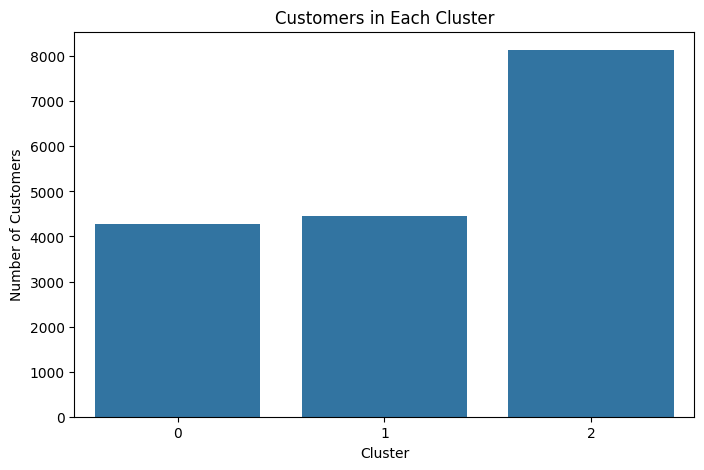

In [5]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=cluster_size.index,
    y=cluster_size.values
)

plt.title("Customers in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.show()

### overall cluster profile:

In [6]:
cluster_profile=(
    df
    .groupby("cluster")
    .mean(numeric_only=True)
    .round(2)
)
cluster_profile

,total_orders,total_revenue,average_order_value,median_spend,max_spend,total_discount,avg_discount_percent,completed_orders,returned_orders,rto_orders,payment_diversity,category_diversity,size_diversity,color_diversity,vendor_diversity,return_rate,total_sessions,total_product_views,total_add_to_cart,total_checkout,total_purchases,website_revenue,view_to_cart_rate,cart_to_checkout_rate,checkout_to_purchase_rate,revenue_per_session,customer_lifetime_value,loyalty_score
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,1.23,3100.50,2517.34,2517.25,2593.67,600.41,15.88,0.80,0.31,0.12,1.16,1.46,1.55,1.59,1.51,0.35,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.00,3100.50,1.59
1,3.18,8204.21,2605.61,2592.65,3144.88,1585.84,15.88,2.07,0.79,0.32,2.30,2.88,3.32,3.61,3.04,0.35,2.91,9.37,2.91,2.91,2.91,7518.62,0.36,1.0,1.0,2601.15,8204.21,7.81
2,1.30,3224.09,2491.78,2491.72,2595.05,610.29,15.63,0.84,0.33,0.13,1.20,1.45,1.56,1.59,1.49,0.35,1.45,4.61,1.45,1.45,1.45,3604.16,0.39,1.0,1.0,2496.21,3224.09,1.71


### Key features (customers):

In [7]:
key_features=[
    "total_orders",
    "total_revenue",
    "average_order_value",
    "total_discount",
    "avg_discount_percent",
    "return_rate",
    "customer_lifetime_value",
    "loyalty_score"
]
cluster_profile[key_features]

,total_orders,total_revenue,average_order_value,total_discount,avg_discount_percent,return_rate,customer_lifetime_value,loyalty_score
cluster,,,,,,,,
0,1.23,3100.50,2517.34,600.41,15.88,0.35,3100.50,1.59
1,3.18,8204.21,2605.61,1585.84,15.88,0.35,8204.21,7.81
2,1.30,3224.09,2491.78,610.29,15.63,0.35,3224.09,1.71


### Revenue by cluster:

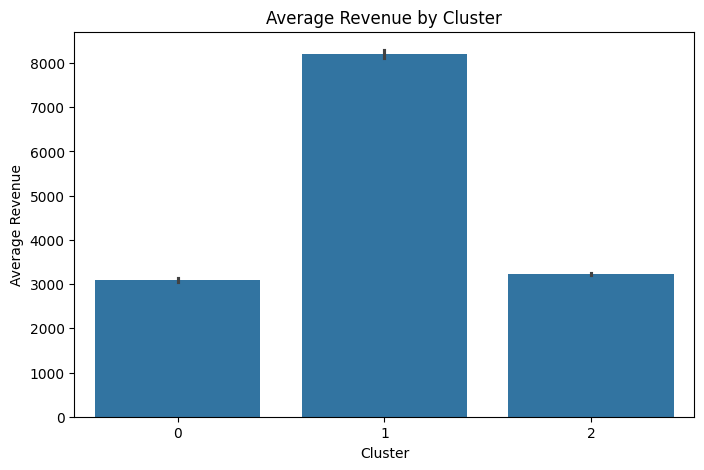

In [8]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="cluster",
    y="total_revenue",
    estimator="mean"
)

plt.title("Average Revenue by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Revenue")
plt.show()

### Order behaviour:

In [9]:
order_profile=(
    df.groupby("cluster")[
        [
            "total_orders",
            "completed_orders",
            "returned_orders",
            "rto_orders",
            "average_order_value"
        ]
    ]
    .mean()
    .round(2)
)
order_profile

,total_orders,completed_orders,returned_orders,rto_orders,average_order_value
cluster,,,,,
0,1.23,0.80,0.31,0.12,2517.34
1,3.18,2.07,0.79,0.32,2605.61
2,1.30,0.84,0.33,0.13,2491.78


### Orders charts:

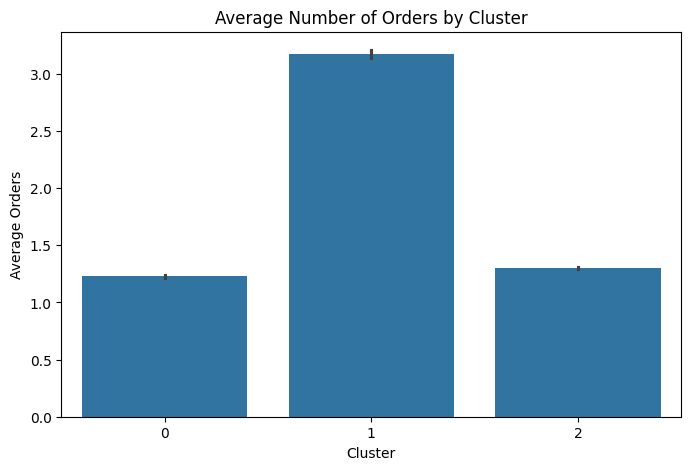

In [10]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="cluster",
    y="total_orders",
    estimator="mean"
)

plt.title("Average Number of Orders by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Orders")
plt.show()

### Customer loyalty:

In [11]:
loyalty_profile=(
    df.groupby("cluster")[
        [
            "loyalty_score",
            "customer_lifetime_value",
            "total_orders"
        ]
    ]
    .mean()
    .round(2)
)
loyalty_profile

,loyalty_score,customer_lifetime_value,total_orders
cluster,,,
0,1.59,3100.50,1.23
1,7.81,8204.21,3.18
2,1.71,3224.09,1.30


### Loyalty chart:

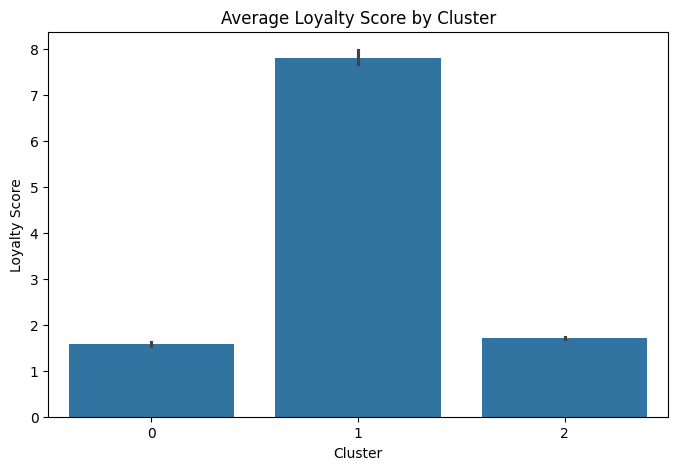

In [12]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="cluster",
    y="loyalty_score",
    estimator="mean"
)

plt.title("Average Loyalty Score by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Loyalty Score")
plt.show()

### Discount behaviour:

In [14]:
discount_profile=(
    df.groupby("cluster")[
        [
            "total_discount",
            "avg_discount_percent"
        ]
    ]
    .mean()
    .round(2)
)
discount_profile

,total_discount,avg_discount_percent
cluster,,
0,600.41,15.88
1,1585.84,15.88
2,610.29,15.63


### Discount chart:

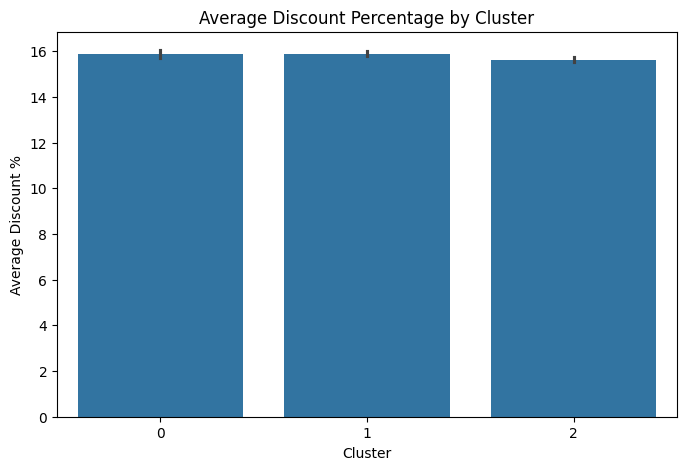

In [15]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="cluster",
    y="avg_discount_percent",
    estimator="mean"
)

plt.title("Average Discount Percentage by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Discount %")
plt.show()

### Return behaviour:

In [16]:
return_profile=(
    df.groupby("cluster")[
        [
            "returned_orders",
            "rto_orders",
            "return_rate"
        ]
    ]
    .mean()
    .round(2)
)
return_profile

,returned_orders,rto_orders,return_rate
cluster,,,
0,0.31,0.12,0.35
1,0.79,0.32,0.35
2,0.33,0.13,0.35


### Return rate chart:

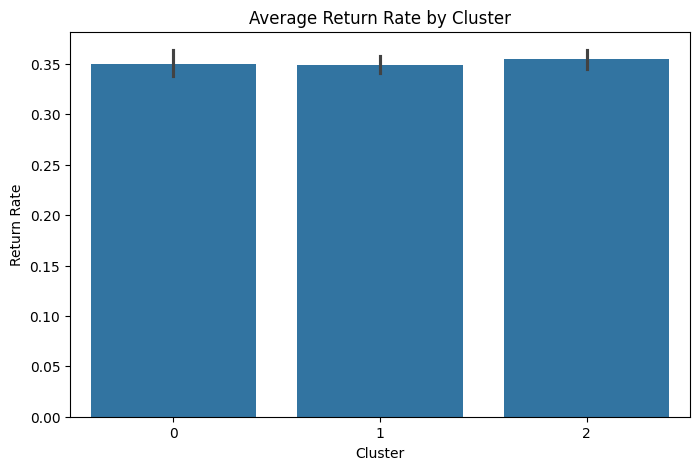

In [17]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="cluster",
    y="return_rate",
    estimator="mean"
)

plt.title("Average Return Rate by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Return Rate")
plt.show()

### Website behaviour (Engagement):

In [18]:
website_profile=(
    df.groupby("cluster")[
        [
            "total_sessions",
            "total_product_views",
            "total_add_to_cart",
            "total_checkout",
            "total_purchases",
            "website_revenue",
            "revenue_per_session"
        ]
    ]
    .mean()
    .round(2)
)
website_profile

,total_sessions,total_product_views,total_add_to_cart,total_checkout,total_purchases,website_revenue,revenue_per_session
cluster,,,,,,,
0,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,2.91,9.37,2.91,2.91,2.91,7518.62,2601.15
2,1.45,4.61,1.45,1.45,1.45,3604.16,2496.21


### Website engagement chart:

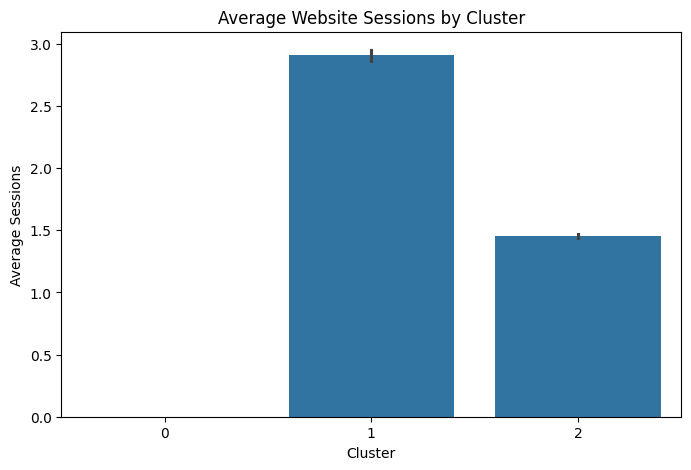

In [19]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="cluster",
    y="total_sessions",
    estimator="mean"
)

plt.title("Average Website Sessions by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Sessions")
plt.show()

### Payment behaviour: (preferred payment method)

In [22]:
profile_df=pd.read_csv(
    PROCESSED/"customer_features.csv"
)
print(profile_df.shape)

(16865, 48)


In [24]:
profile_columns=[
    "customer_id",
    "preferred_payment",
    "favorite_category",
    "city_/_tier",
    "preferred_device",
    "preferred_traffic_source"
]
profile_df[profile_columns].head()

,customer_id,preferred_payment,favorite_category,city_/_tier,preferred_device,preferred_traffic_source
0,CUST-0000001,COD,shirts,Mumbai / Tier 1,mobile,Meta
1,CUST-0000003,COD,pants,Bengaluru / Tier 1,Unknown,Unknown
2,CUST-0000004,Card,pants,Hyderabad / Tier 1,desktop,Google
3,CUST-0000005,COD,croptops,Delhi / Tier 1,Unknown,Unknown
4,CUST-0000007,COD,croptops,Bengaluru / Tier 1,mobile,Meta


### Merging cluster lables:

In [25]:
profile_data = profile_df.merge(
    df[["customer_id", "cluster"]],
    on="customer_id",
    how="inner"
)
print("Profile data shape:", profile_data.shape)
profile_data.head()

Profile data shape: (16865, 49)


,customer_id,name,first_order_date,total_orders,total_revenue,average_order_value,time_to_2nd_purchase,last_purchase_date,city_/_tier,acquisition_channel_(first_touch),repurchased,total_spend,avg_spend,median_spend,max_spend,min_spend,gross_revenue,total_discount,avg_discount,avg_discount_percent,total_orders_actual,completed_orders,returned_orders,rto_orders,preferred_payment,payment_diversity,category_diversity,size_diversity,color_diversity,vendor_diversity,favorite_category,return_rate,total_sessions,total_product_views,total_add_to_cart,total_checkout,total_purchases,website_revenue,view_to_cart_rate,cart_to_checkout_rate,checkout_to_purchase_rate,revenue_per_session,preferred_device,preferred_traffic_source,favorite_campaign,customer_lifetime_value,loyalty_score,value_segment,cluster
0,CUST-0000001,Tejas Sarkar,2025-09-08,1,3356.0,3356.0,0.0,2025-09-08,Mumbai / Tier 1,Meta,0,3356,3356.0,3356.0,3356,3356,3663,307,307.0,8.40,1,0,1,0,COD,1,2,2,2,2,shirts,1.0,1.0,4.0,1.0,1.0,1.0,3356.0,0.250000,1.0,1.0,3356.0,mobile,Meta,KS_Sep25_Camp_46,3356.0,1,Medium,2
1,CUST-0000003,Lila Bedi,2023-09-11,1,2360.0,2360.0,0.0,2023-09-11,Bengaluru / Tier 1,Google,0,2360,2360.0,2360.0,2360,2360,2485,125,125.0,5.00,1,1,0,0,COD,1,1,1,1,1,pants,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,Unknown,Unknown,Unknown,2360.0,1,Low,0
2,CUST-0000004,Hamsini Parekh,2022-03-18,2,4029.0,2014.5,449.0,2023-06-11,Hyderabad / Tier 1,Google,1,4029,2014.5,2014.5,2291,1738,4860,832,416.0,17.50,2,0,2,0,Card,1,2,3,3,3,pants,1.0,4.0,11.0,4.0,4.0,4.0,8058.0,0.363636,1.0,1.0,2014.5,desktop,Google,KS_AlwaysOn,4029.0,2,Medium,2
3,CUST-0000005,Yug Gill,2025-10-16,1,2581.0,2581.0,0.0,2025-10-16,Delhi / Tier 1,Offline (Friends/Family),0,2581,2581.0,2581.0,2581,2581,3584,1003,1003.0,28.00,1,1,0,0,COD,1,2,1,1,2,croptops,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,Unknown,Unknown,Unknown,2581.0,1,Low,0
4,CUST-0000007,Daksha Ramaswamy,2024-03-11,2,5365.0,2682.5,303.0,2025-01-08,Bengaluru / Tier 1,Meta,1,5365,2682.5,2682.5,2994,2371,6679,1314,657.0,19.95,2,0,1,1,COD,2,3,3,2,3,croptops,1.0,2.0,4.0,2.0,2.0,2.0,5365.0,0.500000,1.0,1.0,2682.5,mobile,Meta,KS_AlwaysOn,5365.0,4,High,1


### Payemnt behaviour:

In [26]:
payment_profile=pd.crosstab(
    profile_data["cluster"],
    profile_data["preferred_payment"],
    normalize="index"
).mul(100).round(2)
payment_profile

preferred_payment,COD,Card,NetBanking,UPI,Wallet
cluster,,,,,
0,20.79,34.28,6.48,33.69,4.77
1,31.44,36.83,3.37,27.42,0.94
2,21.84,34.90,5.41,33.63,4.23


### Payemnt Preference chart:

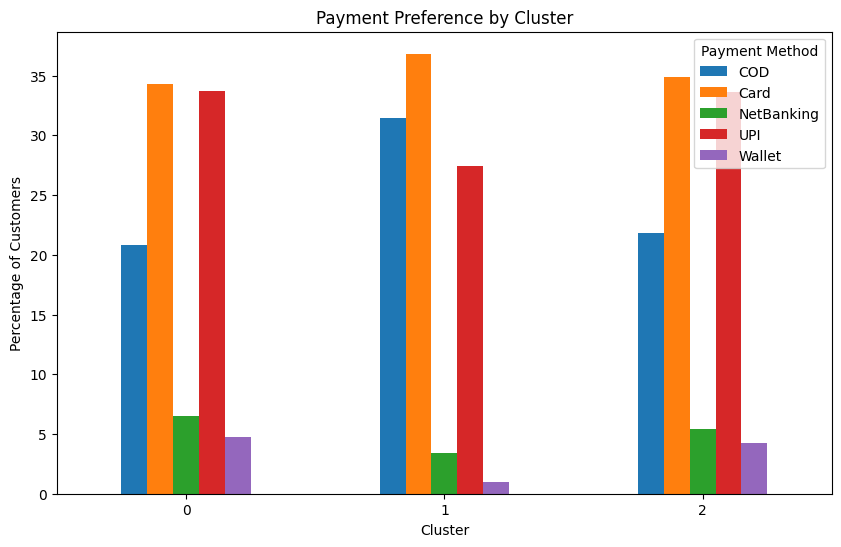

In [27]:
payment_profile.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Payment Preference by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Percentage of Customers")

plt.xticks(rotation=0)
plt.legend(title="Payment Method")
plt.show()

### Category behaviour (fav category):

In [28]:
category_profile=pd.crosstab(
    profile_data["cluster"],
    profile_data["favorite_category"],
    normalize="index"
).mul(100).round(2)
category_profile

favorite_category,croptops,jackets,pants,shirts,shorts,tshirts
cluster,,,,,,
0,18.17,4.51,27.36,40.03,2.83,7.11
1,18.76,2.74,26.67,47.93,0.54,3.35
2,18.49,4.31,28.47,40.22,2.48,6.02


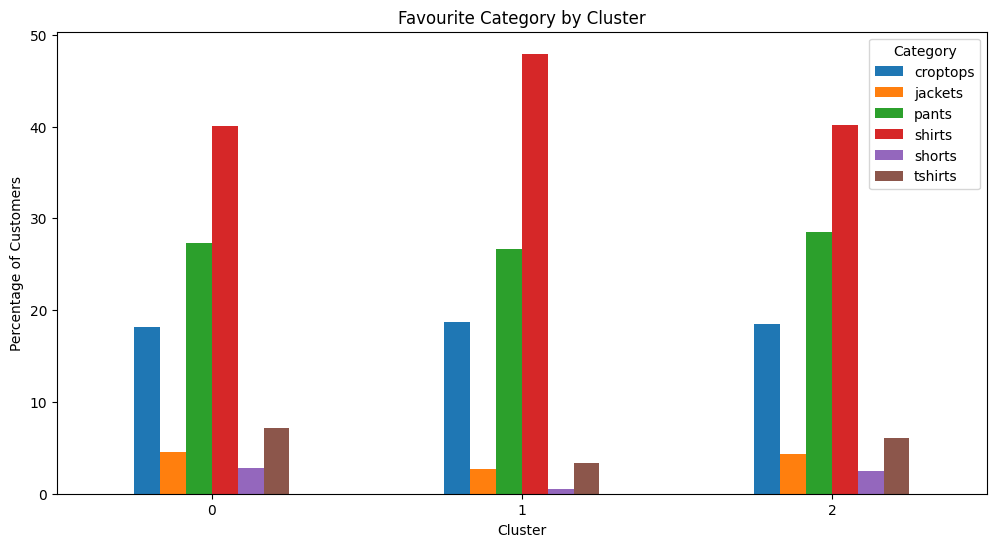

In [29]:
category_profile.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Favourite Category by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Percentage of Customers")

plt.xticks(rotation=0)
plt.legend(title="Category")
plt.show()

### City/tier profile:

In [30]:
tier_profile=pd.crosstab(
    profile_data["cluster"],
    profile_data["city_/_tier"],
    normalize="index"
).mul(100).round(2)
tier_profile

city_/_tier,Ahmedabad / Tier 1,Bengaluru / Tier 1,Bhopal / Tier 2,Bhubaneswar / Tier 2,Chandigarh / Tier 2,Chennai / Tier 1,Coimbatore / Tier 2,Dehradun / Tier 2,Delhi / Tier 1,Gurgaon / Tier 2,Hyderabad / Tier 1,Indore / Tier 2,Jaipur / Tier 2,Kanpur / Tier 2,Kochi / Tier 2,Kolkata / Tier 1,Lucknow / Tier 2,Ludhiana / Tier 2,Mumbai / Tier 1,Mysuru / Tier 2,Nagpur / Tier 2,Nashik / Tier 2,Noida / Tier 2,Patna / Tier 2,Pune / Tier 1,Rajkot / Tier 2,Ranchi / Tier 2,Surat / Tier 2,Vadodara / Tier 2,Visakhapatnam / Tier 2
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,3.93,7.20,2.22,1.38,1.89,4.14,2.06,2.08,10.17,2.95,4.65,2.74,2.95,2.38,2.38,3.09,3.27,1.92,10.71,1.94,2.22,2.06,2.69,2.15,5.59,2.03,1.92,3.04,1.87,2.38
1,3.98,7.28,2.20,1.98,2.40,3.69,2.07,2.07,8.83,2.99,4.99,2.97,2.70,2.04,1.98,2.90,2.72,2.20,11.75,1.96,1.60,1.69,3.10,2.34,6.04,2.56,1.93,3.39,1.75,1.91
2,4.12,6.67,1.83,2.05,2.16,3.86,2.35,1.97,9.17,2.84,5.32,3.07,3.19,2.05,2.21,3.02,3.21,1.84,11.02,2.13,2.11,2.06,3.05,2.22,5.81,2.00,1.92,2.90,2.05,1.78


### City/tier chart:

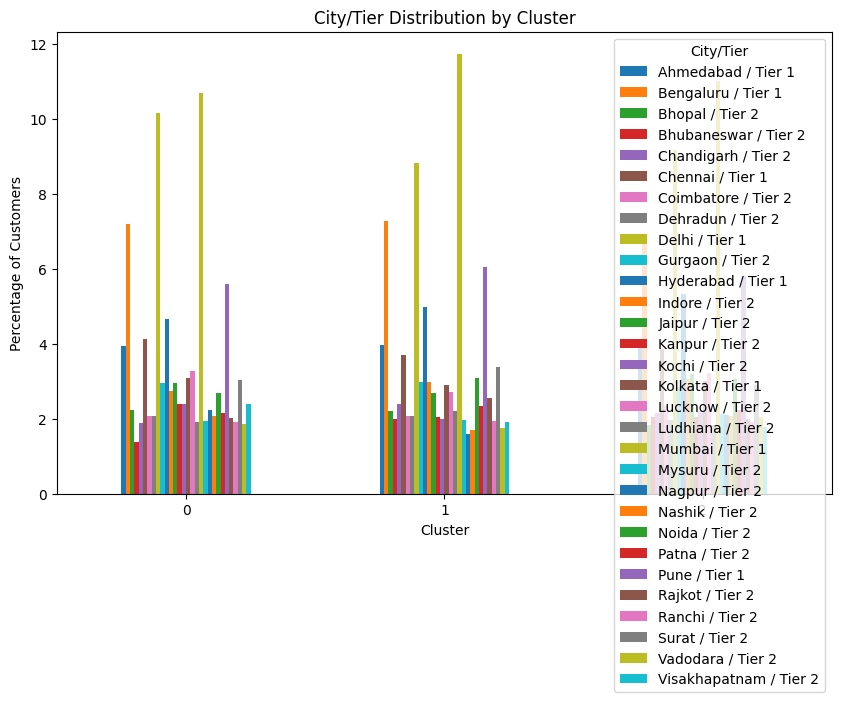

In [31]:
tier_profile.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("City/Tier Distribution by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Percentage of Customers")

plt.xticks(rotation=0)
plt.legend(title="City/Tier")
plt.show()

### Device behaviour (preffered devie):

In [32]:
device_profile=pd.crosstab(
    profile_data["cluster"],
    profile_data["preferred_device"],
    normalize="index"
).mul(100).round(2)
device_profile

preferred_device,Unknown,desktop,mobile,tablet
cluster,,,,
0,100.00,0.00,0.00,0.00
1,0.18,21.28,78.43,0.11
2,0.00,29.84,69.81,0.36


### Chart:

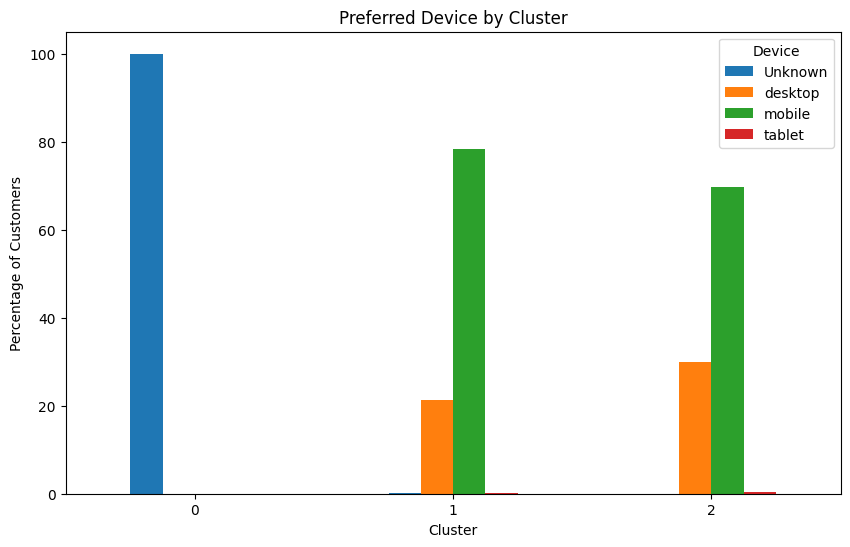

In [33]:
device_profile.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Preferred Device by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Percentage of Customers")

plt.xticks(rotation=0)
plt.legend(title="Device")
plt.show()

### Traffic source:

In [34]:
traffic_profile=pd.crosstab(
    profile_data["cluster"],
    profile_data["preferred_traffic_source"],
    normalize="index"
).mul(100).round(2)
traffic_profile

preferred_traffic_source,Email/SMS,Google,Influencer,Meta,Unknown
cluster,,,,,
0,0.00,0.00,0.00,0.00,100.00
1,11.26,22.38,19.35,46.83,0.18
2,9.45,21.53,20.24,48.78,0.00


### Traffic source chart:

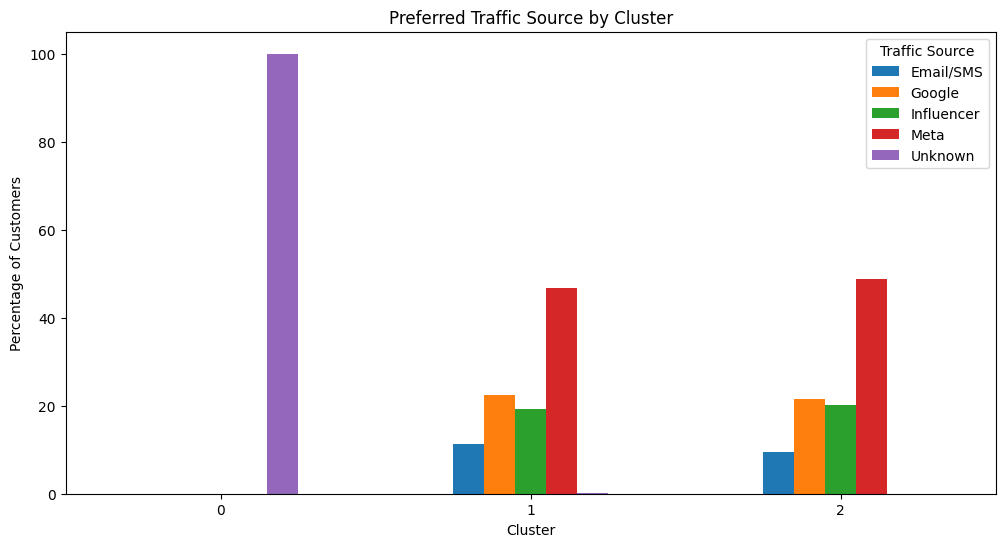

In [35]:
traffic_profile.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Preferred Traffic Source by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Percentage of Customers")

plt.xticks(rotation=0)
plt.legend(title="Traffic Source")
plt.show()

### Key cluster differences:

In [37]:
key_features=[
    "total_orders",
    "total_revenue",
    "average_order_value",
    "total_discount",
    "avg_discount_percent",
    "return_rate",
    "total_sessions",
    "website_revenue",
    "customer_lifetime_value",
    "loyalty_score"
]

cluster_profile=(
    df.groupby("cluster")[key_features]
    .mean()
    .round(2)
)
cluster_profile

,total_orders,total_revenue,average_order_value,total_discount,avg_discount_percent,return_rate,total_sessions,website_revenue,customer_lifetime_value,loyalty_score
cluster,,,,,,,,,,
0,1.23,3100.50,2517.34,600.41,15.88,0.35,0.00,0.00,3100.50,1.59
1,3.18,8204.21,2605.61,1585.84,15.88,0.35,2.91,7518.62,8204.21,7.81
2,1.30,3224.09,2491.78,610.29,15.63,0.35,1.45,3604.16,3224.09,1.71


### Overall average:

In [38]:
overall_mean=(
    df[key_features]
    .mean()
    .round(2)
)
overall_mean

total_orders                  1.78
total_revenue              4506.80
average_order_value        2528.30
total_discount              865.19
avg_discount_percent         15.76
return_rate                   0.35
total_sessions                1.47
website_revenue            3723.01
customer_lifetime_value    4506.80
loyalty_score                 3.29
dtype: float64

### Difference from average:

In [39]:
cluster_difference=(
    cluster_profile
    .subtract(overall_mean)
    .round(2)
)
cluster_difference

,total_orders,total_revenue,average_order_value,total_discount,avg_discount_percent,return_rate,total_sessions,website_revenue,customer_lifetime_value,loyalty_score
cluster,,,,,,,,,,
0,-0.55,-1406.30,-10.96,-264.78,0.12,0.0,-1.47,-3723.01,-1406.30,-1.70
1,1.40,3697.41,77.31,720.65,0.12,0.0,1.44,3795.61,3697.41,4.52
2,-0.48,-1282.71,-36.52,-254.90,-0.13,0.0,-0.02,-118.85,-1282.71,-1.58


### Difference in % :

In [40]:
cluster_relative=(
    cluster_profile
    .div(overall_mean)
    .sub(1)
    .mul(100)
    .round(1)
)
cluster_relative

,total_orders,total_revenue,average_order_value,total_discount,avg_discount_percent,return_rate,total_sessions,website_revenue,customer_lifetime_value,loyalty_score
cluster,,,,,,,,,,
0,-30.9,-31.2,-0.4,-30.6,0.8,0.0,-100.0,-100.0,-31.2,-51.7
1,78.7,82.0,3.1,83.3,0.8,0.0,98.0,102.0,82.0,137.4
2,-27.0,-28.5,-1.4,-29.5,-0.8,0.0,-1.4,-3.2,-28.5,-48.0


### Top differences:

In [41]:
for cluster in cluster_relative.index:
    print(f"\nCluster {cluster}")
    top_features=(
        cluster_relative.loc[cluster]
        .abs()
        .sort_values(ascending=False)
        .head(5)
    )
    print(top_features)


Cluster 0
total_sessions             100.0
website_revenue            100.0
loyalty_score               51.7
total_revenue               31.2
customer_lifetime_value     31.2
Name: 0, dtype: float64

Cluster 1
loyalty_score              137.4
website_revenue            102.0
total_sessions              98.0
total_discount              83.3
customer_lifetime_value     82.0
Name: 1, dtype: float64

Cluster 2
loyalty_score              48.0
total_discount             29.5
customer_lifetime_value    28.5
total_revenue              28.5
total_orders               27.0
Name: 2, dtype: float64


### Customer persona summary (numerical):

In [42]:
persona_features=[
    "total_orders",
    "total_revenue",
    "average_order_value",
    "avg_discount_percent",
    "return_rate",
    "total_sessions",
    "customer_lifetime_value",
    "loyalty_score"
]

persona_summary=(
    df.groupby("cluster")[persona_features]
    .mean()
    .round(2)
)
persona_summary

,total_orders,total_revenue,average_order_value,avg_discount_percent,return_rate,total_sessions,customer_lifetime_value,loyalty_score
cluster,,,,,,,,
0,1.23,3100.50,2517.34,15.88,0.35,0.00,3100.50,1.59
1,3.18,8204.21,2605.61,15.88,0.35,2.91,8204.21,7.81
2,1.30,3224.09,2491.78,15.63,0.35,1.45,3224.09,1.71


### Most common payment method:

In [43]:
top_payment=(
    profile_data
    .groupby("cluster")["preferred_payment"]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else "Unknown")
)
top_payment

cluster
0    Card
1    Card
2    Card
Name: preferred_payment, dtype: object

### Most common category:

In [44]:
top_category=(
    profile_data
    .groupby("cluster")["favorite_category"]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else "Unknown")
)
top_category

cluster
0    shirts
1    shirts
2    shirts
Name: favorite_category, dtype: object

### Most common city:

In [47]:
top_tier=(
    profile_data
    .groupby("cluster")["city_/_tier"]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else "Unknown")
)
top_tier

cluster
0    Mumbai / Tier 1
1    Mumbai / Tier 1
2    Mumbai / Tier 1
Name: city_/_tier, dtype: object

### Most commonly used device:

In [48]:
top_device=(
    profile_data
    .groupby("cluster")["preferred_device"]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else "Unknown")
)
top_device

cluster
0    Unknown
1     mobile
2     mobile
Name: preferred_device, dtype: object

### Most common traffic source:

In [49]:
top_traffic=(
    profile_data
    .groupby("cluster")["preferred_traffic_source"]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else "Unknown")
)
top_traffic

cluster
0    Unknown
1       Meta
2       Meta
Name: preferred_traffic_source, dtype: object

### Summary:

In [50]:
persona_table = persona_summary.copy()

persona_table["preferred_payment"] = top_payment
persona_table["favorite_category"] = top_category
persona_table["city_tier"] = top_tier
persona_table["preferred_device"] = top_device
persona_table["preferred_traffic_source"] = top_traffic

persona_table

,total_orders,total_revenue,average_order_value,avg_discount_percent,return_rate,total_sessions,customer_lifetime_value,loyalty_score,preferred_payment,favorite_category,city_tier,preferred_device,preferred_traffic_source
cluster,,,,,,,,,,,,,
0,1.23,3100.50,2517.34,15.88,0.35,0.00,3100.50,1.59,Card,shirts,Mumbai / Tier 1,Unknown,Unknown
1,3.18,8204.21,2605.61,15.88,0.35,2.91,8204.21,7.81,Card,shirts,Mumbai / Tier 1,mobile,Meta
2,1.30,3224.09,2491.78,15.63,0.35,1.45,3224.09,1.71,Card,shirts,Mumbai / Tier 1,mobile,Meta


In [52]:
cluster_profile.to_csv(PROCESSED/"cluster_profile.csv")

In [53]:
persona_table.to_csv(PROCESSED/"customer_personas.csv")

In [54]:
payment_profile.to_csv(PROCESSED/"payment_profile.csv")

In [55]:
category_profile.to_csv(PROCESSED/"category_profile.csv")

In [56]:
tier_profile.to_csv(PROCESSED/"tier_profile.csv")

### The Conclusion

The three K-Means customer clusters were profiled using both
numerical and categorical customer characteristics.

The analysis covered:

- Revenue and spending
- Order behaviour
- Loyalty
- Discount sensitivity
- Return behaviour
- Website engagement
- Payment preference
- Favourite product category
- City/Tier
- Preferred device
- Traffic source

The resulting customer personas will be used in the next stage
to develop targeted marketing strategies for each Indian D2C
customer segment.

### Main Outputs

- cluster_profile.csv
- customer_personas.csv
- payment_profile.csv
- category_profile.csv
- tier_profile.csv